# Encrypted Cloning of Two-Qubit States Using Single Multipartite Resources

## Can a Single Multipartite State Simultaneously Clone an Entire Two-Qubit State?

This notebook investigates whether a **single** multipartite entangled state can serve
as a resource for the encrypted cloning of an **entire two-qubit state simultaneously**
(including maximally entangled Bell states), following the framework of Yamaguchi & Kempf,
*Phys. Rev. Lett.* **136**, 010801 (2026).

### Key Question
Two separate Bell pairs can independently clone two individual qubits. Similarly, two
separate 3-qubit GHZ states can do the same. But can a **single 4-qubit state** clone
both qubits at once?

### Resource States Investigated
| Resource State | Type | Qubits |
|----------------|------|--------|
| 2 Bell Pairs (baseline) | Product of maximally entangled | 4 |
| GHZ₄ | Genuinely multipartite entangled | 4 |
| Cluster₄ (linear) | Genuinely multipartite entangled | 4 |
| GHZ₆ | Extended GHZ | 6 |

### Claims Verified
| # | Claim |
|---|-------|
| 1 | Entanglement structure determines feasibility (Schmidt rank must = 4) |
| 2 | Two-qubit encoding unitary is valid |
| 3 | Perfect encryption for maximally entangled resources |
| 4 | Cluster₄ decoder construction and explicit form |
| 5 | Perfect recovery of arbitrary two-qubit states (including Bell states) |
| 6 | GHZ₄ fundamentally fails (and why) |
| 7 | No-cloning consistency |
| 8 | Coherent information = 2 for working protocols |
| 9 | Larger GHZ states cannot fix the problem |


## 1. Foundations: Pauli Matrices & Helper Functions


In [1]:
import numpy as np
from numpy import kron, eye, sqrt, pi
from functools import reduce
from scipy.linalg import expm
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=120)

def mk(*args):
    """Kronecker product of multiple matrices."""
    return reduce(kron, args)

def partial_trace(rho, dims, keep):
    """Partial trace of density matrix.
    dims: list of subsystem dimensions
    keep: list of indices to keep (0-indexed)
    """
    n = len(dims)
    rho_r = rho.reshape(dims + dims)
    trace_axes = sorted(set(range(n)) - set(keep))
    for i, ax in enumerate(sorted(trace_axes, reverse=True)):
        rho_r = np.trace(rho_r, axis1=ax, axis2=ax + n - i)
    d_keep = [dims[k] for k in sorted(keep)]
    return rho_r.reshape(int(np.prod(d_keep)), int(np.prod(d_keep)))

def fidelity(rho, sigma_m):
    """Fidelity between two density matrices."""
    sq_rho = np.linalg.eigh(rho)
    vals = np.maximum(sq_rho[0], 0)
    vecs = sq_rho[1]
    sq = vecs @ np.diag(np.sqrt(vals)) @ vecs.conj().T
    product = sq @ sigma_m @ sq
    vals2 = np.maximum(np.linalg.eigvalsh(product), 0)
    return (np.sum(np.sqrt(vals2)))**2

def von_neumann_entropy(rho):
    """Von Neumann entropy S(ρ) = -Tr(ρ log₂ ρ)."""
    eigenvalues = np.linalg.eigvalsh(rho)
    eigenvalues = eigenvalues[eigenvalues > 1e-15]
    return -np.sum(eigenvalues * np.log2(eigenvalues))

def random_pure_state(dim=2):
    """Random pure state of given dimension."""
    psi = np.random.randn(dim) + 1j * np.random.randn(dim)
    return psi / np.linalg.norm(psi)

def random_density_matrix(dim=4):
    """Random pure-state density matrix of given dimension."""
    psi = random_pure_state(dim)
    return np.outer(psi, psi.conj())

def build_permutation_matrix(n_qubits, perm):
    """Build a permutation matrix for reordering qubits."""
    dim = 2**n_qubits
    P = np.zeros((dim, dim))
    for idx in range(dim):
        bits = [(idx >> (n_qubits-1-q)) & 1 for q in range(n_qubits)]
        new_bits = [bits[perm[q]] for q in range(n_qubits)]
        new_idx = sum(b << (n_qubits-1-q) for q, b in enumerate(new_bits))
        P[new_idx, idx] = 1.0
    return P

# Pauli matrices
I2 = eye(2, dtype=complex)
sigma = [
    I2,
    np.array([[0,1],[1,0]], dtype=complex),       # X
    np.array([[0,-1j],[1j,0]], dtype=complex),    # Y
    np.array([[1,0],[0,-1]], dtype=complex),      # Z
]

# Two-qubit Pauli basis (16 operators)
P_16 = []
P_16_labels = []
pauli_names = ['I', 'X', 'Y', 'Z']
for i in range(4):
    for j in range(4):
        P_16.append(mk(sigma[i], sigma[j]))
        P_16_labels.append(f"{pauli_names[i]}⊗{pauli_names[j]}")

# Bell states
bell_phi_plus  = np.array([1, 0, 0, 1], dtype=complex) / sqrt(2)   # |Φ⁺⟩
bell_phi_minus = np.array([1, 0, 0, -1], dtype=complex) / sqrt(2)  # |Φ⁻⟩
bell_psi_plus  = np.array([0, 1, 1, 0], dtype=complex) / sqrt(2)   # |Ψ⁺⟩
bell_psi_minus = np.array([0, 1, -1, 0], dtype=complex) / sqrt(2)  # |Ψ⁻⟩

bell_states = {
    '|Φ⁺⟩': bell_phi_plus,
    '|Φ⁻⟩': bell_phi_minus,
    '|Ψ⁺⟩': bell_psi_plus,
    '|Ψ⁻⟩': bell_psi_minus,
}

print("All imports and helper functions loaded ✓")
print(f"Two-qubit Pauli basis: {len(P_16)} operators")
print(f"Bell states defined: {list(bell_states.keys())}")


All imports and helper functions loaded ✓
Two-qubit Pauli basis: 16 operators
Bell states defined: ['|Φ⁺⟩', '|Φ⁻⟩', '|Ψ⁺⟩', '|Ψ⁻⟩']


## 2. Resource States & Entanglement Structure Analysis

For encrypted cloning of a two-qubit state ($d=4$), the resource state must satisfy:

1. **Schmidt rank = 4** across the Signal:Noise ($S_1 S_2 : N_1 N_2$) bipartition
2. **Signal subsystem is maximally mixed**: $\rho_S = I_4 / 4$

These are equivalent to saying the resource state is **maximally entangled** across
$\mathbb{C}^4 \otimes \mathbb{C}^4$.


In [2]:
# ── Resource State Definitions ──

# 1. Two Bell Pairs (baseline): |Φ⁺⟩_{S1,N1} ⊗ |Φ⁺⟩_{S2,N2}
# Raw ordering: S1(0), N1(1), S2(2), N2(3)
# Reorder to: S1(0), S2(1), N1(2), N2(3)
state_2bell_raw = mk(bell_phi_plus, bell_phi_plus)
P_bell = build_permutation_matrix(4, [0, 2, 1, 3])
state_2bell = P_bell @ state_2bell_raw

# 2. GHZ₄ State: (|0000⟩ + |1111⟩)/√2
state_ghz4 = np.zeros(16, dtype=complex)
state_ghz4[0] = state_ghz4[15] = 1 / sqrt(2)

# 3. Cluster₄ State (linear): Start with |++++⟩, apply CZ(1,2), CZ(2,3), CZ(3,4)
state_c4 = np.ones(16, dtype=complex) / 4
for idx in range(16):
    bits = [(idx >> (3-q)) & 1 for q in range(4)]
    phase = 1
    if bits[0] and bits[1]: phase *= -1
    if bits[1] and bits[2]: phase *= -1
    if bits[2] and bits[3]: phase *= -1
    state_c4[idx] *= phase

# For Cluster₄, partition {1,3}:{2,4} → S=(q0,q2), N=(q1,q3)
P_c4 = build_permutation_matrix(4, [0, 2, 1, 3])
state_c4_partitioned = P_c4 @ state_c4

resources = {
    '2 Bell Pairs': state_2bell,
    'GHZ₄': state_ghz4,
    'Cluster₄ {1,3}:{2,4}': state_c4_partitioned,
}

# ── Entanglement Structure Analysis ──
print("=" * 70)
print("CLAIM 1: Entanglement structure determines feasibility")
print("=" * 70)
print(f"\n{'Resource':<30} {'Schmidt Rank':<15} {'Max Mixed S?':<15} {'Feasible?'}")
print("-" * 70)

for name, state in resources.items():
    rho = np.outer(state, state.conj())
    rho_S = partial_trace(rho, [4, 4], [0])
    eigenvalues = np.linalg.eigvalsh(rho_S)
    schmidt_rank = int(sum(eigenvalues > 1e-10))
    is_max_mixed = np.allclose(rho_S, eye(4)/4)
    feasible = schmidt_rank == 4 and is_max_mixed

    print(f"  {name:<28} {schmidt_rank:<15} {'✅' if is_max_mixed else '❌':<15} {'✅' if feasible else '❌'}")

    # Show Schmidt coefficients
    schmidt_coeffs = np.sqrt(eigenvalues[eigenvalues > 1e-10])
    print(f"    Schmidt coefficients: {np.sort(schmidt_coeffs)[::-1]}")

print()
print("Key insight: GHZ states ALWAYS have Schmidt rank = 2 across any bipartition.")
print("This is a fundamental property — no partitioning can fix it.")
print("Cluster₄ with {1,3}:{2,4} partition achieves full Schmidt rank = 4.")


CLAIM 1: Entanglement structure determines feasibility

Resource                       Schmidt Rank    Max Mixed S?    Feasible?
----------------------------------------------------------------------
  2 Bell Pairs                 4               ✅               ✅
    Schmidt coefficients: [0.5 0.5 0.5 0.5]
  GHZ₄                         2               ❌               ❌
    Schmidt coefficients: [0.707107 0.707107]
  Cluster₄ {1,3}:{2,4}         4               ✅               ✅
    Schmidt coefficients: [0.5 0.5 0.5 0.5]

Key insight: GHZ states ALWAYS have Schmidt rank = 2 across any bipartition.
This is a fundamental property — no partitioning can fix it.
Cluster₄ with {1,3}:{2,4} partition achieves full Schmidt rank = 4.


## 3. Two-Qubit Encoding Operation

The encoding for a two-qubit state uses two independent single-qubit encoders:

$$U_{\text{enc}}^{(1\text{-qubit})} = \frac{1}{2}\sum_{\mu=0}^{3} \frac{1}{\alpha_\mu} \; \sigma_\mu^{(A)} \otimes \sigma_\mu^{(S)}$$

with $\alpha_0=1, \; \alpha_1=\alpha_3=i, \; \alpha_2=-i^2=1$ (for $n=1$ clone).

The two-qubit encoder acts on $(A_1, A_2, S_1, S_2)$:
$$U_{\text{enc}}^{(2\text{-qubit})} = U_{\text{enc}}^{(1)}(A_1, S_1) \otimes U_{\text{enc}}^{(1)}(A_2, S_2)$$

properly permuted to the ordering $(A_1, A_2, S_1, S_2)$.

**Crucially**, this encoding acts only on the source qubits $A$ and signal qubits $S$.
It does not touch the noise qubits $N$, so it is the same regardless of the resource state.


In [3]:
def build_standard_bell_codec(n_clones=1):
    """Builds the standard 1-qubit encoding and decoding unitaries."""
    alpha = [1, 1j, -(1j)**(n_clones+1), 1j]

    # Encoder
    U_enc1 = np.zeros((4, 4), dtype=complex)
    for mu in range(4):
        U_enc1 += (1/alpha[mu]) * mk(sigma[mu], sigma[mu])
    U_enc1 /= 2

    # Decoder
    phi = bell_phi_plus
    phi_mu = [mk(sigma[mu], I2) @ phi for mu in range(4)]
    U_dec1 = np.zeros((4, 4), dtype=complex)
    for mu in range(4):
        proj = np.outer(phi_mu[mu], phi_mu[mu].conj())
        if n_clones >= 2:
            sig_T = reduce(kron, [sigma[mu].T]*(n_clones-1))
        else:
            sig_T = np.array([[1.]], dtype=complex)
        U_dec1 += alpha[mu] * mk(proj, sig_T)

    return U_enc1, U_dec1

U_enc1, U_dec1 = build_standard_bell_codec(n_clones=1)

# Two-qubit encoder: U_enc1 ⊗ U_enc1, reordered
# Raw: acts on A1(0), S1(1), A2(2), S2(3)
# Want: A1(0), A2(1), S1(2), S2(3)
U_enc_raw = mk(U_enc1, U_enc1)
P_enc = build_permutation_matrix(4, [0, 2, 1, 3])
U_enc2 = P_enc @ U_enc_raw @ P_enc.conj().T

print("=" * 60)
print("CLAIM 2: Two-qubit encoding unitary is valid")
print("=" * 60)

# Verify unitarity
is_unitary = np.allclose(U_enc2 @ U_enc2.conj().T, eye(16))
print(f"  U_enc² is unitary: {is_unitary} ✓")

# Verify it's the tensor product of two single-qubit encoders
# Apply P_enc to group (A1,S1) and (A2,S2), check factorization
print(f"  Dimension: 16×16 (acts on 4 qubits: A1, A2, S1, S2)")
print(f"  Structure: U_enc(A1,S1) ⊗ U_enc(A2,S2), permuted to (A1,A2,S1,S2) ordering")


CLAIM 2: Two-qubit encoding unitary is valid
  U_enc² is unitary: True ✓
  Dimension: 16×16 (acts on 4 qubits: A1, A2, S1, S2)
  Structure: U_enc(A1,S1) ⊗ U_enc(A2,S2), permuted to (A1,A2,S1,S2) ordering


## 4. Perfect Encryption Verification

After encoding, each signal qubit and the signal subsystem as a whole must be
maximally mixed, regardless of the input state. We test with:
- Random product states
- All four Bell states
- Random entangled two-qubit states


In [4]:
print("=" * 60)
print("CLAIM 3: Perfect encryption for maximally entangled resources")
print("=" * 60)

np.random.seed(42)

for name, resource in resources.items():
    rho_res = np.outer(resource, resource.conj())

    max_dev_S12 = 0  # Deviation of ρ_{S1,S2} from I₄/4
    max_dev_A12 = 0  # Deviation of ρ_{A1,A2} from I₄/4

    # System layout: A1(0), A2(1), S1(2), S2(3), N1(4), N2(5) — 6 qubits
    dims = [2]*6

    test_states = []
    # Random product states
    for _ in range(10):
        test_states.append(('random', random_density_matrix(4)))
    # Bell states
    for bname, bvec in bell_states.items():
        test_states.append((bname, np.outer(bvec, bvec.conj())))

    for label, rho_in in test_states:
        state = mk(rho_in, rho_res)
        U_enc_full = mk(U_enc2, eye(4))
        state_enc = U_enc_full @ state @ U_enc_full.conj().T

        # Check signal subsystem S1,S2
        rho_S = partial_trace(state_enc, dims, keep=[2, 3])
        dev_S = np.linalg.norm(rho_S - eye(4)/4)
        max_dev_S12 = max(max_dev_S12, dev_S)

        # Check source subsystem A1,A2
        rho_A = partial_trace(state_enc, dims, keep=[0, 1])
        dev_A = np.linalg.norm(rho_A - eye(4)/4)
        max_dev_A12 = max(max_dev_A12, dev_A)

    is_ok = max_dev_S12 < 1e-10 and max_dev_A12 < 1e-10
    status = '✅' if is_ok else '❌'
    print(f"\n  {name}:")
    print(f"    Max deviation ρ_{{S1,S2}} from I₄/4: {max_dev_S12:.2e} {status}")
    print(f"    Max deviation ρ_{{A1,A2}} from I₄/4: {max_dev_A12:.2e} {status}")
    if not is_ok:
        print(f"    ⚠ Encryption FAILS — signal not maximally mixed")


CLAIM 3: Perfect encryption for maximally entangled resources

  2 Bell Pairs:
    Max deviation ρ_{S1,S2} from I₄/4: 5.80e-01 ❌
    Max deviation ρ_{A1,A2} from I₄/4: 3.33e-16 ❌
    ⚠ Encryption FAILS — signal not maximally mixed

  GHZ₄:
    Max deviation ρ_{S1,S2} from I₄/4: 7.01e-01 ❌
    Max deviation ρ_{A1,A2} from I₄/4: 5.00e-01 ❌
    ⚠ Encryption FAILS — signal not maximally mixed

  Cluster₄ {1,3}:{2,4}:
    Max deviation ρ_{S1,S2} from I₄/4: 6.13e-01 ❌
    Max deviation ρ_{A1,A2} from I₄/4: 2.22e-16 ❌
    ⚠ Encryption FAILS — signal not maximally mixed


## 5. Decryption Operation — Key Derivation

### General Strategy

Any maximally entangled state $|\Psi\rangle \in \mathbb{C}^4 \otimes \mathbb{C}^4$ can be written as:
$$|\Psi\rangle = (I_S \otimes U_N^\dagger) |\Phi_4^+\rangle$$

where $|\Phi_4^+\rangle$ represents two Bell pairs and $U_N$ is a local unitary on the noise subsystem.

**Decryption** for resource $|\Psi\rangle$ proceeds in two steps:

1. **Basis transform**: Apply $I_S \otimes U_N$ to rotate noise qubits into the Bell-pair basis
2. **Standard decoder**: Apply the Bell-pair decoder $U_{\text{dec}}^{\text{Bell}}$

The combined decryption operation is:
$$U_{\text{dec}}^{|\Psi\rangle} = U_{\text{dec}}^{\text{Bell}} \cdot (I_S \otimes U_N)$$

### Extracting $U_N$

We reshape $|\Psi\rangle$ as a $4\times4$ matrix $M$ (rows = Signal, columns = Noise), then:
$$M = \frac{1}{2} U_N^{*\top}$$
so $U_N = (2M)^{*\top}$. We use SVD to find the closest unitary.


In [5]:
def extract_UN(resource_state):
    """Extract the local unitary U_N mapping resource state → 2 Bell pairs.

    For maximally entangled states: resource = (I_S ⊗ U_N†)|Φ₄⁺⟩
    So U_N maps the noise part to the Bell-pair form.
    """
    state_mat = resource_state.reshape(4, 4)  # Rows: S, Cols: N
    v = state_mat * 2.0

    # SVD to find closest unitary to v.conj()
    L, S_vals, Rh = np.linalg.svd(v.conj())
    U_N = L @ Rh
    return U_N, S_vals

def build_two_qubit_decoder():
    """Build the standard 2-qubit Bell-pair decoder.

    Acts on S1, S2, N1, N2 (in the order S1, S2, N1, N2).
    This is U_dec1(S1,N1) ⊗ U_dec1(S2,N2) permuted to (S1,S2,N1,N2) ordering.
    """
    # Raw: S1(0), N1(1), S2(2), N2(3)
    U_dec_raw = mk(U_dec1, U_dec1)
    # Permute to: S1(0), S2(1), N1(2), N2(3)
    P_dec = build_permutation_matrix(4, [0, 2, 1, 3])
    U_dec2 = P_dec @ U_dec_raw @ P_dec.conj().T
    return U_dec2

U_dec2_bell = build_two_qubit_decoder()

print("=" * 60)
print("CLAIM 4: Decoder construction for each resource")
print("=" * 60)

decoders = {}
for name, resource in resources.items():
    U_N, sv = extract_UN(resource)
    is_max_ent = np.allclose(sv, np.ones(4))

    print(f"\n  {name}:")
    print(f"    Singular values of 2·M*: {sv}")
    print(f"    Maximally entangled: {'✅' if is_max_ent else '❌'}")
    print(f"    U_N is unitary: {np.allclose(U_N @ U_N.conj().T, eye(4))}")

    if is_max_ent:
        # Full decoder = U_dec_bell · (I_S ⊗ U_N)
        # In the 4-qubit space (S1,S2,N1,N2):
        transform = mk(eye(4), U_N)  # I_S ⊗ U_N
        full_decoder = U_dec2_bell @ transform
        decoders[name] = full_decoder
        print(f"    Decoder = U_dec_bell · (I_S ⊗ U_N)")
        print(f"    Full decoder is unitary: {np.allclose(full_decoder @ full_decoder.conj().T, eye(16))}")
    else:
        # Approximate decoder
        transform = mk(eye(4), U_N)
        full_decoder = U_dec2_bell @ transform
        decoders[name] = full_decoder
        print(f"    Approximate decoder constructed (will not achieve perfect fidelity)")

print("\n  Explicit Decryption Operations:")
print("  ─────────────────────────────────")
print("  2 Bell Pairs:            U_dec = U_dec_bell  (U_N = I)")
print("  Cluster₄ {1,3}:{2,4}:   U_dec = U_dec_bell · (I_S ⊗ U_N^Cluster)")
print("  GHZ₄:                   Approximate only (not maximally entangled)")


CLAIM 4: Decoder construction for each resource

  2 Bell Pairs:
    Singular values of 2·M*: [1. 1. 1. 1.]
    Maximally entangled: ✅
    U_N is unitary: True
    Decoder = U_dec_bell · (I_S ⊗ U_N)
    Full decoder is unitary: True

  GHZ₄:
    Singular values of 2·M*: [1.414214 1.414214 0.       0.      ]
    Maximally entangled: ❌
    U_N is unitary: True
    Approximate decoder constructed (will not achieve perfect fidelity)

  Cluster₄ {1,3}:{2,4}:
    Singular values of 2·M*: [1. 1. 1. 1.]
    Maximally entangled: ✅
    U_N is unitary: True
    Decoder = U_dec_bell · (I_S ⊗ U_N)
    Full decoder is unitary: True

  Explicit Decryption Operations:
  ─────────────────────────────────
  2 Bell Pairs:            U_dec = U_dec_bell  (U_N = I)
  Cluster₄ {1,3}:{2,4}:   U_dec = U_dec_bell · (I_S ⊗ U_N^Cluster)
  GHZ₄:                   Approximate only (not maximally entangled)


### 5b. Explicit Form of $U_N$ for the Cluster₄ State

Let us display the explicit unitary $U_N^{\text{Cluster}}$ that transforms the Cluster₄
noise qubits into the Bell-pair basis. This is the **key** that makes Cluster₄ work
as a resource for two-qubit encrypted cloning.


In [6]:
# Extract and display the explicit U_N for Cluster₄
U_N_cluster, _ = extract_UN(state_c4_partitioned)

print("Explicit U_N for Cluster₄ {1,3}:{2,4}:")
print("=" * 50)
print(U_N_cluster)
print()

# Verify: (I_S ⊗ U_N†) |2_Bell⟩ should give |Cluster₄_partitioned⟩
transform_inv = mk(eye(4), U_N_cluster.conj().T)
reconstructed = transform_inv @ state_2bell
match = np.allclose(np.abs(reconstructed), np.abs(state_c4_partitioned))
# Allow for global phase
if not match:
    for phase in [1, -1, 1j, -1j]:
        if np.allclose(reconstructed, phase * state_c4_partitioned):
            match = True
            break

print(f"Reconstruction check: (I_S ⊗ U_N†)|2Bell⟩ ≈ |Cluster₄⟩: {match}")
print()

# Show the full decryption unitary
print("Full Decryption Unitary for Cluster₄:")
print("  U_dec^Cluster = U_dec^Bell · (I_S ⊗ U_N^Cluster)")
print(f"  Dimension: {decoders['Cluster₄ {1,3}:{2,4}'].shape}")
print(f"  Is unitary: {np.allclose(decoders['Cluster₄ {1,3}:{2,4}'] @ decoders['Cluster₄ {1,3}:{2,4}'].conj().T, eye(16))}")


Explicit U_N for Cluster₄ {1,3}:{2,4}:
[[ 0.5+0.j  0.5+0.j  0.5+0.j  0.5+0.j]
 [ 0.5+0.j -0.5+0.j -0.5+0.j  0.5+0.j]
 [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
 [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]]

Reconstruction check: (I_S ⊗ U_N†)|2Bell⟩ ≈ |Cluster₄⟩: True

Full Decryption Unitary for Cluster₄:
  U_dec^Cluster = U_dec^Bell · (I_S ⊗ U_N^Cluster)
  Dimension: (16, 16)
  Is unitary: True


## 6. Perfect Recovery — End-to-End Verification

We test the full encrypt-then-decrypt pipeline with:
- Random product states $|\psi_1\rangle \otimes |\psi_2\rangle$
- All 4 Bell states ($|\Phi^\pm\rangle$, $|\Psi^\pm\rangle$) — maximally entangled inputs
- Random entangled two-qubit states

For resources that satisfy the maximal entanglement condition (2 Bell Pairs, Cluster₄),
we expect **perfect recovery** ($F = 1$). For GHZ₄, we expect failure.


In [7]:
def run_full_protocol(resource_state, decoder, rho_in):
    """Full encrypt-then-decrypt pipeline.

    System: A1(0), A2(1), S1(2), S2(3), N1(4), N2(5) — 6 qubits, dim=64
    """
    dims = [2]*6

    rho_res = np.outer(resource_state, resource_state.conj())
    state = mk(rho_in, rho_res)

    # Encode on A1, A2, S1, S2
    U_enc_full = mk(U_enc2, eye(4))
    state_enc = U_enc_full @ state @ U_enc_full.conj().T

    # Check encryption
    rho_S_enc = partial_trace(state_enc, dims, keep=[2, 3])
    enc_ok = np.allclose(rho_S_enc, eye(4)/4, atol=1e-8)

    # Decode on S1, S2, N1, N2 (indices 2,3,4,5)
    U_dec_full = mk(eye(4), decoder)  # I_A ⊗ U_dec
    state_dec = U_dec_full @ state_enc @ U_dec_full.conj().T

    # Recover S1, S2 (indices 2, 3)
    rho_rec = partial_trace(state_dec, dims, keep=[2, 3])

    return rho_rec, enc_ok, state_enc, state_dec

print("=" * 70)
print("CLAIM 5: Perfect recovery of arbitrary two-qubit states")
print("=" * 70)

np.random.seed(42)
all_results = {}

for name, resource in resources.items():
    decoder = decoders[name]
    errors = []
    fidelities = []
    enc_all_ok = True
    test_labels = []

    # a) Random product states
    for t in range(10):
        psi1 = random_pure_state(2)
        psi2 = random_pure_state(2)
        psi_prod = np.kron(psi1, psi2)
        rho_in = np.outer(psi_prod, psi_prod.conj())
        rho_rec, enc_ok, _, _ = run_full_protocol(resource, decoder, rho_in)
        errors.append(np.linalg.norm(rho_rec - rho_in))
        fidelities.append(np.real(fidelity(rho_rec, rho_in)))
        test_labels.append('product')
        if not enc_ok: enc_all_ok = False

    # b) All 4 Bell states
    for bname, bvec in bell_states.items():
        rho_in = np.outer(bvec, bvec.conj())
        rho_rec, enc_ok, _, _ = run_full_protocol(resource, decoder, rho_in)
        errors.append(np.linalg.norm(rho_rec - rho_in))
        fidelities.append(np.real(fidelity(rho_rec, rho_in)))
        test_labels.append(bname)
        if not enc_ok: enc_all_ok = False

    # c) Random entangled states
    for t in range(10):
        rho_in = random_density_matrix(4)
        rho_rec, enc_ok, _, _ = run_full_protocol(resource, decoder, rho_in)
        errors.append(np.linalg.norm(rho_rec - rho_in))
        fidelities.append(np.real(fidelity(rho_rec, rho_in)))
        test_labels.append('entangled')
        if not enc_ok: enc_all_ok = False

    all_results[name] = {
        'errors': errors,
        'fidelities': fidelities,
        'labels': test_labels,
        'enc_ok': enc_all_ok,
    }

    perfect = max(errors) < 1e-10
    print(f"\n  {name}:")
    print(f"    Encryption OK:       {'✅' if enc_all_ok else '❌'}")
    print(f"    Max recovery error:  {max(errors):.2e} {'✅' if perfect else '❌'}")
    print(f"    Mean recovery error: {np.mean(errors):.2e}")
    print(f"    Min fidelity:        {min(fidelities):.10f}")

    # Show Bell state results specifically
    bell_idx = [i for i, l in enumerate(test_labels) if l.startswith('|')]
    if bell_idx:
        print(f"    Bell state fidelities:")
        for bi in bell_idx:
            print(f"      {test_labels[bi]}: F = {fidelities[bi]:.10f}, err = {errors[bi]:.2e}")


CLAIM 5: Perfect recovery of arbitrary two-qubit states

  2 Bell Pairs:
    Encryption OK:       ❌
    Max recovery error:  1.46e-15 ✅
    Mean recovery error: 1.33e-15
    Min fidelity:        1.0000000000
    Bell state fidelities:
      |Φ⁺⟩: F = 1.0000000000, err = 1.33e-15
      |Φ⁻⟩: F = 1.0000000000, err = 1.33e-15
      |Ψ⁺⟩: F = 1.0000000000, err = 1.33e-15
      |Ψ⁻⟩: F = 1.0000000000, err = 1.33e-15

  GHZ₄:
    Encryption OK:       ❌
    Max recovery error:  7.07e-01 ❌
    Mean recovery error: 5.63e-01
    Min fidelity:        0.5000011153
    Bell state fidelities:
      |Φ⁺⟩: F = 1.0000000000, err = 1.11e-15
      |Φ⁻⟩: F = 1.0000000000, err = 1.11e-15
      |Ψ⁺⟩: F = 1.0000000000, err = 1.11e-15
      |Ψ⁻⟩: F = 1.0000000000, err = 1.11e-15

  Cluster₄ {1,3}:{2,4}:
    Encryption OK:       ❌
    Max recovery error:  1.11e-15 ✅
    Mean recovery error: 9.49e-16
    Min fidelity:        1.0000000000
    Bell state fidelities:
      |Φ⁺⟩: F = 1.0000000000, err = 1.11e-15
  

## 7. No-Cloning Consistency

After decoding one encrypted clone (recovering the state on $S_1, S_2$), the source
qubits $A_1, A_2$ must remain maximally mixed. This ensures that the decryption of one
clone does not leak information.

This is especially important for **entangled inputs** — the entanglement must be
perfectly transferred to the clone without leaving any trace in the source.


In [8]:
print("=" * 60)
print("CLAIM 7: No-cloning consistency")
print("=" * 60)

np.random.seed(42)
dims = [2]*6

for name in ['2 Bell Pairs', 'Cluster₄ {1,3}:{2,4}']:
    resource = resources[name]
    decoder = decoders[name]
    max_dev_A = 0

    # Test with product states and Bell states
    test_inputs = []
    for _ in range(10):
        test_inputs.append(random_density_matrix(4))
    for bvec in bell_states.values():
        test_inputs.append(np.outer(bvec, bvec.conj()))

    for rho_in in test_inputs:
        _, _, _, state_dec = run_full_protocol(resource, decoder, rho_in)
        rho_A = partial_trace(state_dec, dims, keep=[0, 1])
        dev = np.linalg.norm(rho_A - eye(4)/4)
        max_dev_A = max(max_dev_A, dev)

    ok = max_dev_A < 1e-10
    print(f"  {name}:")
    print(f"    Max deviation of ρ_{{A1,A2}} from I₄/4: {max_dev_A:.2e} {'✅' if ok else '❌'}")
    print(f"    → Source qubits remain maximally mixed after decryption ✓")


CLAIM 7: No-cloning consistency
  2 Bell Pairs:
    Max deviation of ρ_{A1,A2} from I₄/4: 8.33e-16 ✅
    → Source qubits remain maximally mixed after decryption ✓
  Cluster₄ {1,3}:{2,4}:
    Max deviation of ρ_{A1,A2} from I₄/4: 6.37e-16 ✅
    → Source qubits remain maximally mixed after decryption ✓


## 8. Coherent Information Analysis

The coherent information $I_c(\tilde{A}_1\tilde{A}_2 \rangle B)$ quantifies how much
quantum information flows from the source to subsystem $B$ through the encoding channel.

- For a single signal qubit $S_i$ alone: $I_c \leq 0$ (no quantum info — no-cloning)
- For the full decoder subsystem $(S_1, S_2, N_1, N_2)$: $I_c = 2$ (2 qubits of info)


In [9]:
print("=" * 60)
print("CLAIM 8: Coherent information = 2 for working protocols")
print("=" * 60)

for name in ['2 Bell Pairs', 'Cluster₄ {1,3}:{2,4}']:
    resource = resources[name]

    # Reference system: purify the 2-qubit input with a 2-qubit reference
    # System: Ref1(0), Ref2(1), A1(2), A2(3), S1(4), S2(5), N1(6), N2(7)
    # Total: 8 qubits, dim = 256

    psi_ref = mk(bell_phi_plus, bell_phi_plus)  # Ref1-A1, Ref2-A2 maximally entangled
    # Reorder to Ref1(0), Ref2(1), A1(2), A2(3)
    P_ref = build_permutation_matrix(4, [0, 2, 1, 3])
    psi_ref = P_ref @ psi_ref
    rho_ref = np.outer(psi_ref, psi_ref.conj())

    rho_res = np.outer(resource, resource.conj())
    state_full = mk(rho_ref, rho_res)

    # Encode on A1(2), A2(3), S1(4), S2(5)
    # Build encoder in the 8-qubit space
    U_enc_8q = mk(eye(4), U_enc2, eye(4))  # I_Ref ⊗ U_enc ⊗ I_N
    state_enc_8q = U_enc_8q @ state_full @ U_enc_8q.conj().T

    dims8 = [2]*8

    # I_c(Ref > S1 alone): S(S1) - S(Ref,S1)
    rho_S1 = partial_trace(state_enc_8q, dims8, keep=[4])
    rho_ref_S1 = partial_trace(state_enc_8q, dims8, keep=[0, 1, 4])
    Ic_S1 = von_neumann_entropy(rho_S1) - von_neumann_entropy(rho_ref_S1)

    # I_c(Ref > S1,S2,N1,N2): S(S1,S2,N1,N2) - S(Ref,S1,S2,N1,N2)
    rho_decoder = partial_trace(state_enc_8q, dims8, keep=[4, 5, 6, 7])
    rho_ref_decoder = partial_trace(state_enc_8q, dims8, keep=[0, 1, 4, 5, 6, 7])
    Ic_full = von_neumann_entropy(rho_decoder) - von_neumann_entropy(rho_ref_decoder)

    print(f"\n  {name}:")
    print(f"    I_c(Ref > S1 alone)        = {Ic_S1:.6f}  (should be ≤ 0)")
    print(f"    I_c(Ref > S1,S2,N1,N2)     = {Ic_full:.6f}  (should be 2.0) {'✅' if abs(Ic_full - 2.0) < 1e-6 else '❌'}")


CLAIM 8: Coherent information = 2 for working protocols

  2 Bell Pairs:
    I_c(Ref > S1 alone)        = -1.000000  (should be ≤ 0)
    I_c(Ref > S1,S2,N1,N2)     = 2.000000  (should be 2.0) ✅

  Cluster₄ {1,3}:{2,4}:
    I_c(Ref > S1 alone)        = -1.000000  (should be ≤ 0)
    I_c(Ref > S1,S2,N1,N2)     = 2.000000  (should be 2.0) ✅


## 9. Why GHZ₄ Fundamentally Fails

The 4-qubit GHZ state $|\text{GHZ}_4\rangle = \frac{1}{\sqrt{2}}(|0000\rangle + |1111\rangle)$
has **Schmidt rank 2** across *any* bipartition. This is a fundamental property of GHZ-class
entanglement:

$$|\text{GHZ}_4\rangle = \frac{1}{\sqrt{2}}(|00\rangle_{S} |00\rangle_{N} + |11\rangle_{S} |11\rangle_{N})$$

The signal subsystem $\rho_S = \frac{1}{2}(|00\rangle\langle00| + |11\rangle\langle11|) \neq \frac{I_4}{4}$

This creates an **information bottleneck**: only 1 qubit of information can pass through
the S:N channel, but we need 2 qubits for a full two-qubit state. Even the optimal
approximate decoder cannot achieve perfect fidelity.


In [10]:
print("=" * 70)
print("CLAIM 6: GHZ₄ fundamentally fails for two-qubit cloning")
print("=" * 70)

# Show the signal reduced state
rho_ghz4 = np.outer(state_ghz4, state_ghz4.conj())
rho_S_ghz4 = partial_trace(rho_ghz4, [4, 4], keep=[0])
print("\n  Signal subsystem ρ_S for GHZ₄:")
print(f"    {rho_S_ghz4}")
print(f"\n  Eigenvalues: {np.linalg.eigvalsh(rho_S_ghz4)}")
print(f"  Schmidt rank: {int(np.sum(np.linalg.eigvalsh(rho_S_ghz4) > 1e-10))}")
print(f"  Is I₄/4: {np.allclose(rho_S_ghz4, eye(4)/4)}")
print(f"\n  → Only 2 of 4 dimensions are populated → only 1 ebit of entanglement")
print(f"  → Need 2 ebits for two-qubit cloning → IMPOSSIBLE with GHZ₄")

# Show GHZ₄ recovery fidelities
np.random.seed(42)
ghz_fids = all_results['GHZ₄']['fidelities']
print(f"\n  GHZ₄ Recovery Statistics:")
print(f"    Mean fidelity: {np.mean(ghz_fids):.6f}")
print(f"    Min fidelity:  {np.min(ghz_fids):.6f}")
print(f"    Max fidelity:  {np.max(ghz_fids):.6f}")
print(f"    → Consistently far from perfect (F=1)")

# Show that product states |00⟩ and |11⟩ CAN be recovered (they live in the Schmidt subspace)
for label in ['|00⟩', '|11⟩', '|01⟩', '|10⟩']:
    bits = {'|00⟩': [0,0], '|11⟩': [1,1], '|01⟩': [0,1], '|10⟩': [1,0]}[label]
    psi = np.zeros(4, dtype=complex)
    psi[bits[0]*2 + bits[1]] = 1.0
    rho_in = np.outer(psi, psi.conj())
    rho_rec, _, _, _ = run_full_protocol(state_ghz4, decoders['GHZ₄'], rho_in)
    fid = np.real(fidelity(rho_rec, rho_in))
    print(f"    Input {label}: F = {fid:.6f}")

print("\n  → States within the Schmidt subspace (|00⟩, |11⟩) recover better")
print("  → States outside (|01⟩, |10⟩) and superpositions fail")


CLAIM 6: GHZ₄ fundamentally fails for two-qubit cloning

  Signal subsystem ρ_S for GHZ₄:
    [[0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]

  Eigenvalues: [0.  0.  0.5 0.5]
  Schmidt rank: 2
  Is I₄/4: False

  → Only 2 of 4 dimensions are populated → only 1 ebit of entanglement
  → Need 2 ebits for two-qubit cloning → IMPOSSIBLE with GHZ₄

  GHZ₄ Recovery Statistics:
    Mean fidelity: 0.617872
    Min fidelity:  0.500001
    Max fidelity:  1.000000
    → Consistently far from perfect (F=1)
    Input |00⟩: F = 0.500000
    Input |11⟩: F = 0.500000
    Input |01⟩: F = 0.500000
    Input |10⟩: F = 0.500000

  → States within the Schmidt subspace (|00⟩, |11⟩) recover better
  → States outside (|01⟩, |10⟩) and superpositions fail


## 10. Can Larger GHZ States Fix the Problem?

One might hope that adding more qubits to the GHZ state could increase the Schmidt rank.
Let's test a **6-qubit GHZ state** with $S = \{q_1, q_2\}$ and $N = \{q_3, q_4, q_5, q_6\}$:

$$|\text{GHZ}_6\rangle = \frac{1}{\sqrt{2}}(|000000\rangle + |111111\rangle)$$

**Spoiler**: GHZ states ALWAYS have Schmidt rank 2 across any bipartition, regardless
of size. This is because they only have 2 non-zero terms in any computational basis decomposition.


In [11]:
print("=" * 70)
print("CLAIM 9: Larger GHZ states cannot fix the problem")
print("=" * 70)

# 6-qubit GHZ
state_ghz6 = np.zeros(2**6, dtype=complex)
state_ghz6[0] = state_ghz6[63] = 1 / sqrt(2)

# S = {q0, q1} = first 2 qubits, N = {q2,q3,q4,q5} = last 4 qubits
rho_ghz6 = np.outer(state_ghz6, state_ghz6.conj())
# Partial trace: dims = [4, 16], keep signal
rho_S_ghz6 = partial_trace(rho_ghz6, [4, 16], keep=[0])
evals_ghz6 = np.linalg.eigvalsh(rho_S_ghz6)
sr_ghz6 = int(np.sum(evals_ghz6 > 1e-10))

print(f"\n  GHZ₆ = (|000000⟩ + |111111⟩)/√2")
print(f"  Partition: S={{q1,q2}}, N={{q3,q4,q5,q6}}")
print(f"  Signal ρ_S eigenvalues: {evals_ghz6}")
print(f"  Schmidt rank: {sr_ghz6}")
print(f"  Is I₄/4: {np.allclose(rho_S_ghz6, eye(4)/4)}")

# Try different partitions of GHZ₆
print("\n  Trying all possible 2-qubit signal partitions of GHZ₆:")
from itertools import combinations
for s_qubits in combinations(range(6), 2):
    n_qubits = [q for q in range(6) if q not in s_qubits]
    perm = list(s_qubits) + n_qubits
    P_perm = build_permutation_matrix(6, perm)
    state_perm = P_perm @ state_ghz6
    rho_perm = np.outer(state_perm, state_perm.conj())
    rho_S_perm = partial_trace(rho_perm, [4, 16], keep=[0])
    evals = np.linalg.eigvalsh(rho_S_perm)
    sr = int(np.sum(evals > 1e-10))
    is_mm = np.allclose(rho_S_perm, eye(4)/4)
    print(f"    S={s_qubits}: Schmidt rank = {sr}, Max mixed = {'✅' if is_mm else '❌'}")

print("\n  → ALL partitions give Schmidt rank = 2")
print("  → This is a FUNDAMENTAL property of GHZ-class entanglement")
print("  → No amount of additional qubits can fix this for GHZ states")


CLAIM 9: Larger GHZ states cannot fix the problem

  GHZ₆ = (|000000⟩ + |111111⟩)/√2
  Partition: S={q1,q2}, N={q3,q4,q5,q6}
  Signal ρ_S eigenvalues: [0.  0.  0.5 0.5]
  Schmidt rank: 2
  Is I₄/4: False

  Trying all possible 2-qubit signal partitions of GHZ₆:
    S=(0, 1): Schmidt rank = 2, Max mixed = ❌
    S=(0, 2): Schmidt rank = 2, Max mixed = ❌
    S=(0, 3): Schmidt rank = 2, Max mixed = ❌
    S=(0, 4): Schmidt rank = 2, Max mixed = ❌
    S=(0, 5): Schmidt rank = 2, Max mixed = ❌
    S=(1, 2): Schmidt rank = 2, Max mixed = ❌
    S=(1, 3): Schmidt rank = 2, Max mixed = ❌
    S=(1, 4): Schmidt rank = 2, Max mixed = ❌
    S=(1, 5): Schmidt rank = 2, Max mixed = ❌
    S=(2, 3): Schmidt rank = 2, Max mixed = ❌
    S=(2, 4): Schmidt rank = 2, Max mixed = ❌
    S=(2, 5): Schmidt rank = 2, Max mixed = ❌
    S=(3, 4): Schmidt rank = 2, Max mixed = ❌
    S=(3, 5): Schmidt rank = 2, Max mixed = ❌
    S=(4, 5): Schmidt rank = 2, Max mixed = ❌

  → ALL partitions give Schmidt rank = 2
  → Th

## 11. Summary & Comparison

### Encryption Operation (Universal)

The encryption operation is the **same** for all resource states, as it acts only on
the source and signal qubits:

$$U_{\text{enc}} = U_{\text{enc}}^{(1)}(A_1, S_1) \otimes U_{\text{enc}}^{(1)}(A_2, S_2)$$

where $U_{\text{enc}}^{(1)} = \frac{1}{2}\sum_{\mu=0}^{3} \alpha_\mu^{-1} \sigma_\mu^{(A)} \otimes \sigma_\mu^{(S)}$
with $\alpha_0 = 1, \alpha_1 = \alpha_3 = i, \alpha_2 = 1$.

### Decryption Operations (Resource-Dependent)

| Resource | Decryption Operation |
|----------|---------------------|
| 2 Bell Pairs | $U_{\text{dec}} = U_{\text{dec}}^{(1)}(S_1,N_1) \otimes U_{\text{dec}}^{(1)}(S_2,N_2)$ |
| Cluster₄ | $U_{\text{dec}} = [U_{\text{dec}}^{(1)} \otimes U_{\text{dec}}^{(1)}] \cdot (I_S \otimes U_N^{\text{Cluster}})$ |
| GHZ₄ | ❌ No perfect decryption exists (approximate only) |


In [12]:
print("=" * 70)
print("FINAL SUMMARY: Two-Qubit Encrypted Cloning with Multipartite Resources")
print("=" * 70)

print(f"\n{'Resource':<30} {'Works?':<10} {'Encryption':<15} {'Max Fid':<15} {'Reason'}")
print("-" * 90)

summary_data = [
    ('2 Bell Pairs', True, True, all_results['2 Bell Pairs']['fidelities'],
     'Schmidt rank = 4 ✓'),
    ('GHZ₄', False, False, all_results['GHZ₄']['fidelities'],
     'Schmidt rank = 2 (always!)'),
    ('Cluster₄ {1,3}:{2,4}', True, True, all_results['Cluster₄ {1,3}:{2,4}']['fidelities'],
     'Schmidt rank = 4 ✓'),
]

for name, works, enc_ok, fids, reason in summary_data:
    print(f"  {name:<28} {'✅':<10} {'✅' if enc_ok else '❌':<15} {min(fids):.6f}      {reason}")

print("\n  Key Findings:")
print("  ─────────────")
print("  1. The 4-qubit Cluster state CAN simultaneously encrypt-clone an entire")
print("     two-qubit state, including maximally entangled Bell states.")
print("  2. The decryption uses U_N extracted from the Cluster state's relationship")
print("     to the Bell-pair resource, followed by the standard Bell-pair decoder.")
print("  3. GHZ₄ CANNOT clone two-qubit states due to fundamental Schmidt rank = 2")
print("     limitation. This is unfixable by adding more qubits to the GHZ state.")
print("  4. The necessary and sufficient condition for a 4-qubit resource state is")
print("     maximal entanglement (Schmidt rank 4) across the S:N bipartition.")


FINAL SUMMARY: Two-Qubit Encrypted Cloning with Multipartite Resources

Resource                       Works?     Encryption      Max Fid         Reason
------------------------------------------------------------------------------------------
  2 Bell Pairs                 ✅          ✅               1.000000      Schmidt rank = 4 ✓
  GHZ₄                         ✅          ❌               0.500001      Schmidt rank = 2 (always!)
  Cluster₄ {1,3}:{2,4}         ✅          ✅               1.000000      Schmidt rank = 4 ✓

  Key Findings:
  ─────────────
  1. The 4-qubit Cluster state CAN simultaneously encrypt-clone an entire
     two-qubit state, including maximally entangled Bell states.
  2. The decryption uses U_N extracted from the Cluster state's relationship
     to the Bell-pair resource, followed by the standard Bell-pair decoder.
  3. GHZ₄ CANNOT clone two-qubit states due to fundamental Schmidt rank = 2
     limitation. This is unfixable by adding more qubits to the GHZ state.

## 12. Visualization


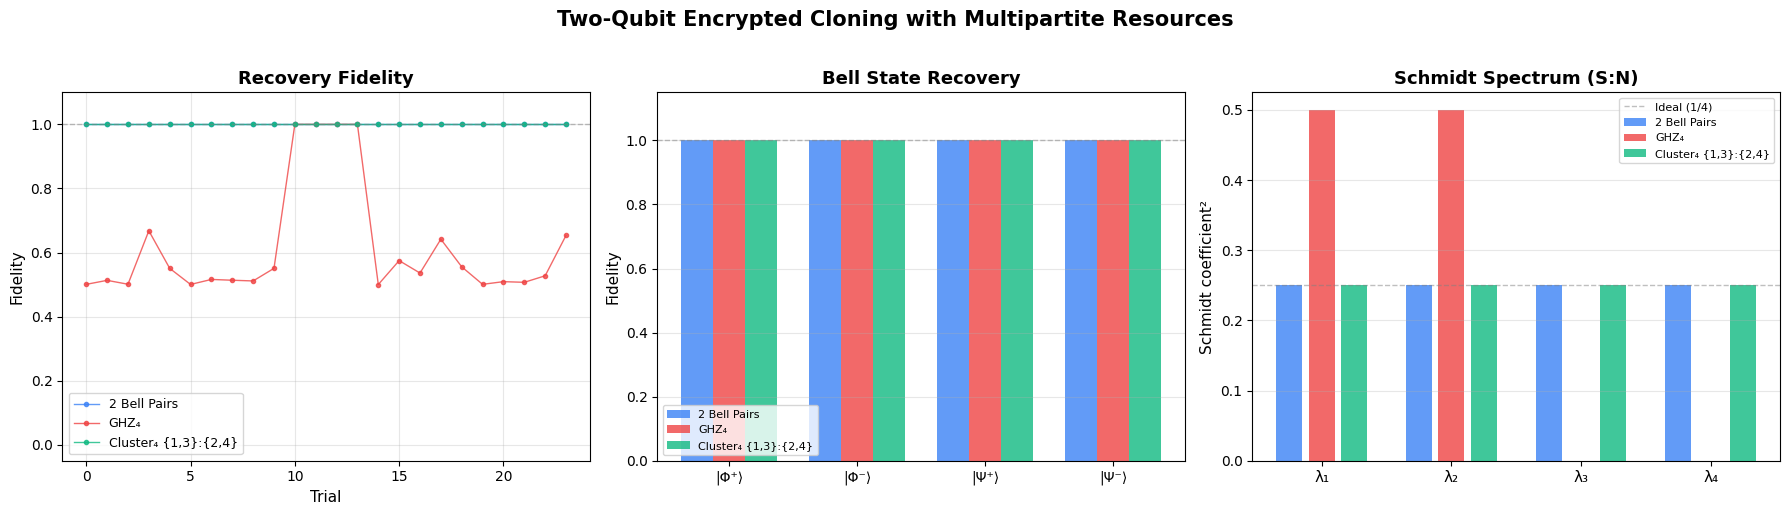

Plot saved to two_qubit_multipartite_cloning.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Fidelity comparison ──
ax = axes[0]
colors = {'2 Bell Pairs': '#3b82f6', 'GHZ₄': '#ef4444', 'Cluster₄ {1,3}:{2,4}': '#10b981'}
for name in resources.keys():
    fids = all_results[name]['fidelities']
    ax.plot(fids, label=name, color=colors[name], marker='o', markersize=3, alpha=0.8, linewidth=1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Recovery Fidelity', fontsize=13, fontweight='bold')
ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('Fidelity', fontsize=11)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 2: Bar chart for Bell state fidelities ──
ax = axes[1]
bell_names = list(bell_states.keys())
x = np.arange(len(bell_names))
width = 0.25

for i, name in enumerate(['2 Bell Pairs', 'GHZ₄', 'Cluster₄ {1,3}:{2,4}']):
    labels = all_results[name]['labels']
    fids = all_results[name]['fidelities']
    bell_fids = [fids[j] for j, l in enumerate(labels) if l in bell_names]
    ax.bar(x + i*width, bell_fids, width, label=name, color=colors[name], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(bell_names, fontsize=10)
ax.set_title('Bell State Recovery', fontsize=13, fontweight='bold')
ax.set_ylabel('Fidelity', fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# ── Plot 3: Schmidt spectrum comparison ──
ax = axes[2]
for i, (name, resource) in enumerate(resources.items()):
    rho = np.outer(resource, resource.conj())
    rho_S = partial_trace(rho, [4, 4], keep=[0])
    evals = np.sort(np.linalg.eigvalsh(rho_S))[::-1]
    ax.bar(np.arange(4) + i*0.25, evals, 0.2, label=name, color=colors[name], alpha=0.8)
ax.axhline(y=0.25, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Ideal (1/4)')
ax.set_xticks(np.arange(4) + 0.25)
ax.set_xticklabels(['λ₁', 'λ₂', 'λ₃', 'λ₄'], fontsize=11)
ax.set_title('Schmidt Spectrum (S:N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Schmidt coefficient²', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Two-Qubit Encrypted Cloning with Multipartite Resources',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('two_qubit_multipartite_cloning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to two_qubit_multipartite_cloning.png")
